# Import Required Libraries

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')



import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split
import torch.optim as optim
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from braindecode.models import EEGITNet
from braindecode import EEGClassifier
from skorch.callbacks import LRScheduler

In [3]:
class EEGEpochExtractor:
    def __init__(self, data_dir):
        """
        Initialize the extractor with the directory containing EDF files.
        """
        self.data_dir = data_dir
        self.all_epochs = []

    # --- Trail classification ---
    @staticmethod
    def trail_classification(trail_num: int) -> str:
        if trail_num in [4, 6, 8, 10, 12, 14]:
            return "imaginary"
        elif trail_num in [1, 2]:
            return "baseline"
        else:
            return "motor"

    # --- Event type classification ---
    @staticmethod
    def event_type_classification(trail_num: int):
        if trail_num in [1, 2]:
            return ("rest", "NA", "NA")
        elif trail_num in [3, 4, 7, 8, 11, 12]:
            return ("rest", "left_fist", "right_fist")
        elif trail_num in [5, 6, 9, 10, 13, 14]:
            return ("rest", "both_fist", "both_feet")

    # --- Metadata extraction ---
    def extract_metadata(self) -> pd.DataFrame:
        metadata = []

        for subj in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subj)
            if not os.path.isdir(subj_path):
                continue

            for file in sorted(os.listdir(subj_path)):
                if file.endswith(".edf") and not file.endswith(".edf.event"):
                    match = re.search(r"R(\d{2})\.edf$", file)
                    if match:
                        trial_num = int(match.group(1))
                        trail_type = self.trail_classification(trial_num)
                        event_type = self.event_type_classification(trial_num)

                        edf_file = os.path.join(subj_path, file)
                        event_file = edf_file + ".event" if os.path.exists(edf_file + ".event") else None

                        metadata.append({
                            "subject": subj,
                            "trial": trial_num,
                            "trail_type": trail_type,
                            "edf_file": edf_file,
                            "event_file": event_file,
                            "T0": event_type[0],
                            "T1": event_type[1],
                            "T2": event_type[2],
                        })

        self.metadata_df = pd.DataFrame(metadata)
        return self.metadata_df


    def process_file(self, file_path, event_id_mapping):
        """
        Process a single EDF file and return epochs.
        """
        print(f"Processing: {file_path}")
        raw_edf = mne.io.read_raw_edf(file_path, preload=True)
        annotations_edf = mne.read_annotations(file_path)

        # Update annotation descriptions
        new_descriptions = [
            event_id_mapping.get(desc, desc) for desc in annotations_edf.description
        ]
        annotations_edf.description = new_descriptions
        
        # Set updated annotations
        raw_edf.set_annotations(annotations_edf)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw_edf)
        
        
        epochs = mne.Epochs(
            raw=raw_edf,
            events=events,
            event_id= event_id,
            reject = None,
            flat = None, 
            reject_by_annotation= False, 
            baseline=None,
            preload=True
        )
        return epochs

    def process_all(self):
        """
        Process all EDF files in the directory and store their epochs.
        """
        metadata_info = self.extract_metadata() # Metadata Information
        metadata_info = metadata_info[metadata_info["trail_type"] == "imaginary"]
        self.all_epochs = []  # reset list
        for filename in metadata_info["edf_file"].tolist():
            if filename.endswith(".edf"):
                event_id_mapping = {"T0": metadata_info[(metadata_info["edf_file"]==filename)]["T0"].values[0], 
                                    "T1": metadata_info[(metadata_info["edf_file"]==filename)]["T1"].values[0], 
                                    "T2": metadata_info[(metadata_info["edf_file"]==filename)]["T2"].values[0]}
                print(event_id_mapping)
                epochs = self.process_file(file_path=filename, event_id_mapping= event_id_mapping)
                self.all_epochs.append(epochs)
        
        print(f"\nTotal EDF files processed: {len(self.all_epochs)}")
        return self.all_epochs


In [4]:
extractor = EEGEpochExtractor(data_dir= "../data/Original/")
all_epochs = extractor.process_all()

{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S001/S001R04.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S001/S001R06.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R06.edf...
EDF file detected
Se

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3410369348.py:69: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_edf = mne.io.read_raw_edf(file_path, preload=True)
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3410369348.py:79: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_edf.set_annotations(annotations_edf)
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3410369348.py:69: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_edf = mne.io.read_raw_edf(file_path, preload=True)
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3410369348.py:79: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_edf.set_annotations(annotations_edf)
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3410369348.py:69: RuntimeWarning: Limited 1 annotation(s) that were

No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S101/S101R06.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S101/S101R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'left_fist', 'T2': 'right_fist'}
Processing: ../data/Original/S101/S101R08.edf
Extracting EDF parameters from /Use

# Extracting Data - X, Y

In [15]:
X, y, groups = [], [], []

for group_id, epochs in enumerate(all_epochs):
    try:
        print(f"Processing participant #{group_id}")

        # Skip empty or invalid epochs
        if len(epochs) == 0:
            print(f"Skipping participant #{group_id}: empty epochs")
            continue

        # Extract data
        l_freq = 0.5 # low-pass cutoff in Hz
        h_freq = 30.0 # High-pass cutoff in Hz
        epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
        X_epoch = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
        y_epoch_event_mapping = epochs.event_id
        y_epoch = epochs.events[:, 2]  # event ids

        # Map event codes to labels (string form)
        y_epoch = np.array(y_epoch, dtype=object)
        for key, value in y_epoch_event_mapping.items():
            y_epoch[y_epoch == value] = str(key)

        # Add group info
        group_epoch = [group_id] * len(y_epoch)

        # Append
        X.append(X_epoch)
        y.extend(y_epoch)
        groups.extend(group_epoch)

    except Exception as e:
        print(f"Error processing participant #{group_id}: {e}")
        continue

# --- Align time dimension before concatenation ---
if len(X) == 0:
    X = np.empty((0, 64, 113))  # fallback shape
else:
    # Find min time dimension
    min_time = min(x.shape[2] for x in X)
    print(f"Aligning all epochs to {min_time} time samples")

    # Truncate each to same time length
    X = [x[:, :, :min_time] for x in X]

    # Safe concatenation
    X = np.concatenate(X, axis=0)

y = np.array(y, dtype=object)
groups = np.array(groups)

print("Final shapes:")
print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)


Processing participant #0
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1057 samples (6.606 s)

Processing participant #1
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition ban

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')


Processing participant #3
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1057 samples (6.606 s)

Processing participant #4
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition ban

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')


Processing participant #6
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1057 samples (6.606 s)

Processing participant #7
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition ban

...

Processing participant #648
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1057 samples (6.606 s)

Processing participant #649
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')


- Filter length: 1057 samples (6.606 s)

Processing participant #652
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 1057 samples (6.606 s)

Processing participant #653
Setting up band-pass filter from 0.5 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper p

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_18728/3835845086.py:15: RuntimeWarning: filter_length (1057) is longer than the signal (113), distortion is likely. Reduce filter length or filter a longer signal.
  epochs.filter(l_freq= l_freq, h_freq = h_freq, method = 'fir')


Final shapes:
X: (19022, 64, 91)
y: (19022,)
groups: (19022,)


In [16]:
Y_CAT_MAPPING = {"rest" : 0,
                "both_feet" : 1, 
                "both_fist" : 2, 
                "left_fist" : 3, 
                "right_fist" : 4}

for key, value in Y_CAT_MAPPING.items():
        y[y == key] = value

In [17]:
X = X[(y != 0)] # Excluding label "rest" instances
y = y[(y != 0)]

# Building Model Architecture - Using Braindecode

In [18]:
# -----------------------------
# 1. Device configuration
# -----------------------------
def get_device():
    if torch.backends.mps.is_available():
        device = torch.device("mps")
        print("✅ Using Apple MPS device.")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
        print("✅ Using CUDA device.")
    else:
        device = torch.device("cpu")
        print("⚠️ Using CPU.")
    return device


# -----------------------------
# 2. Data preprocessing
# -----------------------------
def prepare_data(X, y, test_size=0.2, val_size=0.1):
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y_encoded, dtype=torch.long)

    # Split train/test first
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_tensor, y_tensor, test_size=test_size, random_state=42, stratify=y_encoded
    )

    # Split remaining into validation and test
    val_ratio = val_size / (1 - test_size)
    X_valid, X_test, y_valid, y_test = train_test_split(
        X_temp, y_temp, test_size=1 - val_ratio, random_state=42, stratify=y_temp
    )

    train_ds = TensorDataset(X_train, y_train)
    valid_ds = TensorDataset(X_valid, y_valid)
    test_ds = TensorDataset(X_test, y_test)

    print(f"Train set: {len(train_ds)}, Valid set: {len(valid_ds)}, Test set: {len(test_ds)}")
    return train_ds, valid_ds, test_ds, len(le.classes_)


# -----------------------------
# 3. Model setup
# -----------------------------
def create_model(n_chans, n_outputs, n_times, sfreq, device):
    model = EEGITNet(
        n_chans=n_chans,
        n_outputs=n_outputs,
        n_times=n_times,
        sfreq=sfreq
    )
    model.to(device)
    return model


# -----------------------------
# 4. Training setup
# -----------------------------
def train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=10, batch_size=16):
    lr = 0.0625 * 0.01
    weight_decay = 0

    clf = EEGClassifier(
        model,
        criterion=nn.CrossEntropyLoss(),
        optimizer=torch.optim.AdamW,
        optimizer__lr=lr,
        optimizer__weight_decay=weight_decay,
        batch_size=batch_size,
        train_split=None,  # We'll pass valid_ds manually
        callbacks=[
            "accuracy",
            ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
        ],
        device=device,
        classes=list(range(num_classes)),
        max_epochs=n_epochs,
    )

    # Train using both train and valid sets
    print("🚀 Training started...")
    clf.fit(train_ds, y=None)
    print("✅ Training completed.")

    return clf


# -----------------------------
# 5. Evaluation
# -----------------------------
def evaluate_model(clf, test_ds):
    test_loader = DataLoader(test_ds, batch_size=16, shuffle=False)
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            preds = clf.predict(X_batch)
            y_true.extend(y_batch.numpy())
            y_pred.extend(preds)

    acc = (torch.tensor(y_true) == torch.tensor(y_pred)).float().mean().item()
    print(f"🧠 Test Accuracy: {acc:.4f}")
    return acc, y_true, y_pred



device = get_device()

train_ds, valid_ds, test_ds, num_classes = prepare_data(X, y)
model = create_model(n_chans=64, n_outputs=num_classes, n_times=91, sfreq = 160,device=device)
clf = train_model(model, train_ds, valid_ds, num_classes, device, n_epochs=100, batch_size=32)


✅ Using Apple MPS device.
Train set: 7870, Valid set: 246, Test set: 1722
🚀 Training started...
  epoch    train_accuracy    train_loss      lr     dur
-------  ----------------  ------------  ------  ------
      1            0.3831        1.3957  0.0006  2.8833
      2            0.4163        1.3254  0.0006  2.7063
      3            0.4483        1.2820  0.0006  2.7193
      4            0.4553        1.2574  0.0006  2.6800
      5            0.4733        1.2443  0.0006  2.7084
      6            0.4699        1.2278  0.0006  2.7097
      7            0.4981        1.2217  0.0006  2.7061
      8            0.4667        1.2179  0.0006  2.7031
      9            0.5097        1.2047  0.0006  2.6985
     10            0.5154        1.1956  0.0006  2.7507
     11            0.5215        1.1900  0.0006  2.7036
     12            0.5269        1.1833  0.0006  2.7057
     13            0.5333        1.1813  0.0006  2.7026
     14            0.5355        1.1720  0.0006  2.7047
     15 

# Train Predictions

🧠 Test Accuracy: 0.5901
              precision    recall  f1-score   support

           0       0.56      0.60      0.58      1964
           1       0.52      0.58      0.55      1972
           2       0.67      0.61      0.64      1984
           3       0.63      0.58      0.60      1950

    accuracy                           0.59      7870
   macro avg       0.60      0.59      0.59      7870
weighted avg       0.60      0.59      0.59      7870



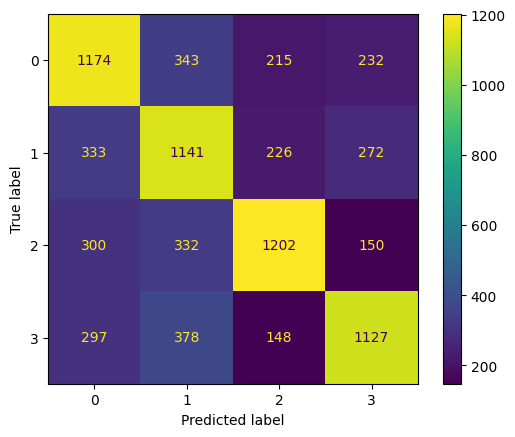

In [19]:
acc, y_true_train, y_pred = evaluate_model(clf, train_ds)
cm = confusion_matrix(y_true_train, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true_train, y_pred))

# Test Predictions

🧠 Test Accuracy: 0.5569
              precision    recall  f1-score   support

           0       0.54      0.58      0.56       430
           1       0.47      0.52      0.50       431
           2       0.63      0.58      0.60       434
           3       0.60      0.55      0.57       427

    accuracy                           0.56      1722
   macro avg       0.56      0.56      0.56      1722
weighted avg       0.56      0.56      0.56      1722



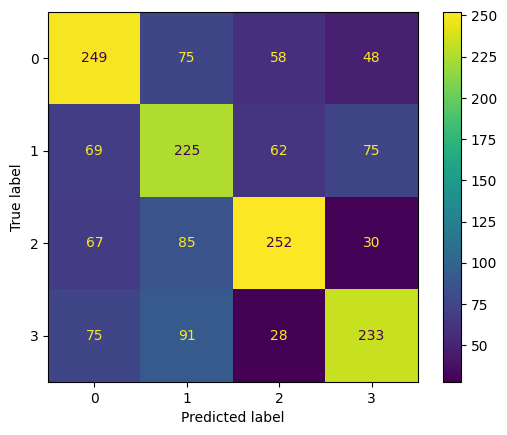

In [20]:
acc, y_true, y_pred = evaluate_model(clf, test_ds)
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(num_classes)))
disp.plot() # will appear at the end of the output
print(classification_report(y_true, y_pred))